<a href="https://colab.research.google.com/github/swathivenkatesan87/24ADI003-24BAD122-ML/blob/main/Exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scenario 1 – Association Rule Mining using Apriori Algorithm:
In this experiment, we applied the Apriori algorithm to identify frequent itemsets and generate association rules from transactional data. The dataset consisted of customer transactions, with each transaction listing purchased items. After preprocessing the data and converting it into a one-hot encoded format, we generated frequent itemsets based on a minimum support threshold. Association rules were then created using confidence and lift measures, which helped identify strong and meaningful relationships between items. Visualizations included a bar chart of the top frequent itemsets, a support vs confidence scatter plot, and a network graph representing the top association rules. The analysis allowed us to observe the effect of different support thresholds, evaluate rule strength, and interpret patterns that could guide business decisions, such as product placement or promotions.

Saving Groceries_dataset.csv.zip to Groceries_dataset.csv (5).zip
Dataset Preview:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Number of transactions: 3898
Number of unique items: 167

Top Frequent Itemsets:
       support                        itemsets
113   0.458184                    (whole milk)
69    0.376603              (other vegetables)
84    0.349666                    (rolls/buns)
94    0.313494                          (soda)
114   0.282966                        (yogurt)
106   0.233710                (tropical fruit)
85    0.230631               (root vegetables)
7     0.213699                 (bottled water)
89    0.206003                       (sausage)
1050  0.191380  (whole milk, other vegetables)

Number of rules generated: 5788
  a

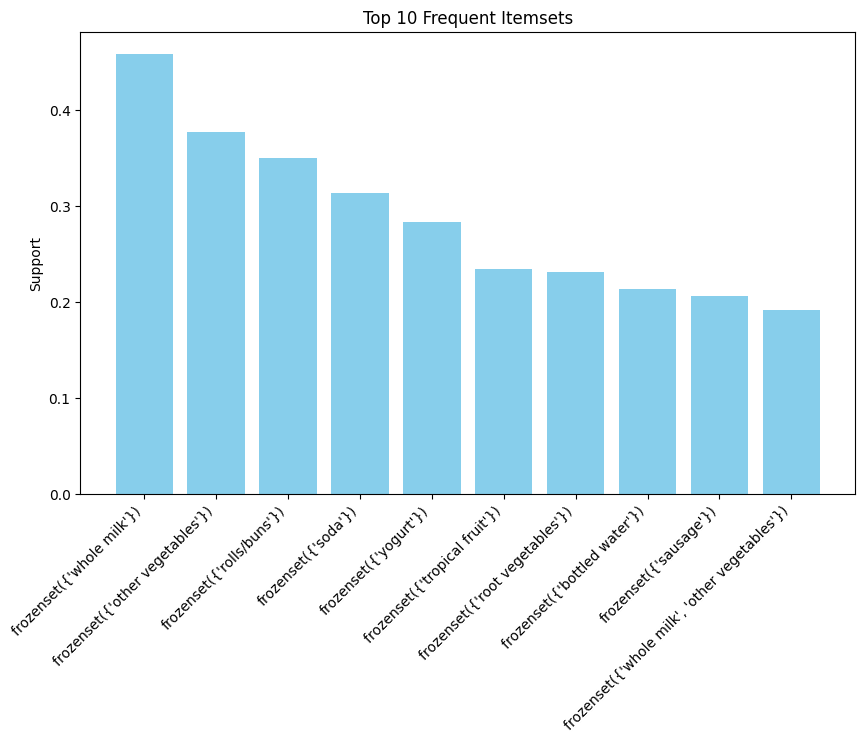

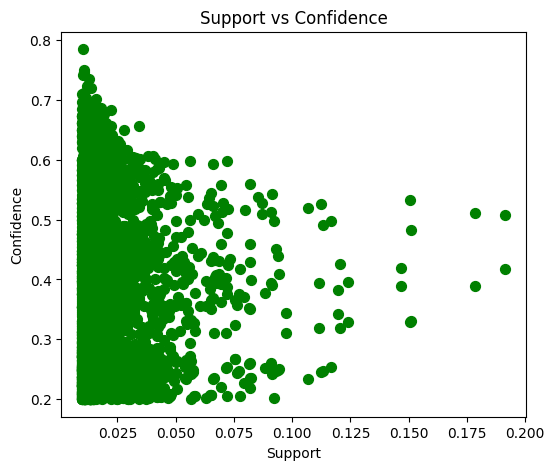

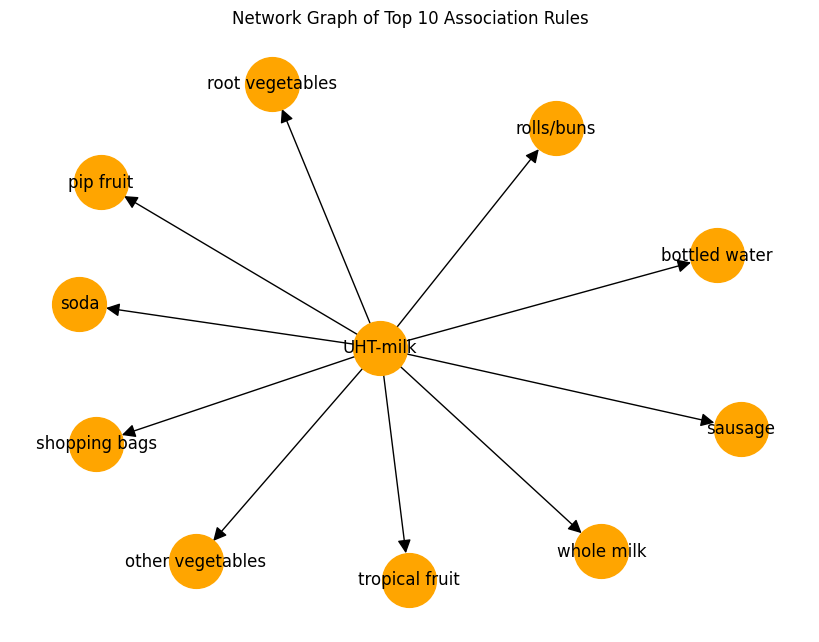


Top 5 Association Rules:
Rule: {'UHT-milk'} -> {'bottled water'}
Support: 0.021, Confidence: 0.271, Lift: 1.269

Rule: {'UHT-milk'} -> {'other vegetables'}
Support: 0.039, Confidence: 0.497, Lift: 1.319

Rule: {'UHT-milk'} -> {'pip fruit'}
Support: 0.017, Confidence: 0.219, Lift: 1.283

Rule: {'UHT-milk'} -> {'rolls/buns'}
Support: 0.031, Confidence: 0.395, Lift: 1.131

Rule: {'UHT-milk'} -> {'root vegetables'}
Support: 0.021, Confidence: 0.268, Lift: 1.162

Effect of different support thresholds on itemsets:
Support 0.01: 3016 itemsets found
Support 0.03: 415 itemsets found
Support 0.05: 165 itemsets found


In [ ]:
#SWATHI V 24BAD122

# 1. Install Library
!pip install mlxtend --quiet

#  2. Import Libraries
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

#  3. Load Dataset
from google.colab import files
uploaded = files.upload()  # Upload Groceries_dataset.csv

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Dataset Preview:")
print(df.head())

# 4. Preprocess Data
# Group items by Member_number (each member = one transaction)
transactions = df.groupby('Member_number')['itemDescription'].apply(list).values.tolist()

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"\nNumber of transactions: {len(transactions)}")
print(f"Number of unique items: {df_encoded.shape[1]}")

# 5. Generate Frequent Itemsets
min_support = 0.01  # Lowered to get more rules
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
print(f"\nTop Frequent Itemsets:")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

# 6. Generate Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules[rules['lift'] > 1]

print(f"\nNumber of rules generated: {len(rules)}")
if len(rules) > 0:
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
else:
    print("No rules generated. Try lowering thresholds further.")

#  7. Visualizations
if len(rules) > 0:
    # 7a. Top Frequent Itemsets Bar Chart
    top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
    plt.figure(figsize=(10,6))
    plt.bar(range(len(top_items)), top_items['support'], color='skyblue')
    plt.xticks(range(len(top_items)), [str(x) for x in top_items['itemsets']], rotation=45, ha='right')
    plt.ylabel('Support')
    plt.title('Top 10 Frequent Itemsets')
    plt.show()

    # 7b. Support vs Confidence Scatter Plot
    plt.figure(figsize=(6,5))
    plt.scatter(rules['support'], rules['confidence'], color='green', s=50)
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Support vs Confidence')
    plt.show()

    # 7c. Network Graph of Association Rules (Top 10)
    G = nx.DiGraph()
    for _, row in rules.head(10).iterrows():
        for antecedent in row['antecedents']:
            for consequent in row['consequents']:
                G.add_edge(antecedent, consequent, weight=row['lift'])

    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='orange', node_size=1500, arrowsize=20)
    plt.title("Network Graph of Top 10 Association Rules")
    plt.show()
else:
    print("No visualization possible; no rules generated.")

# 8. Top 5 Rules
if len(rules) > 0:
    print("\nTop 5 Association Rules:")
    for index, row in rules.head(5).iterrows():
        print(f"Rule: {set(row['antecedents'])} -> {set(row['consequents'])}")
        print(f"Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.3f}\n")

# 9. Effect of Support Threshold
print("Effect of different support thresholds on itemsets:")
for support in [0.01, 0.03, 0.05]:
    fi = apriori(df_encoded, min_support=support, use_colnames=True)
    print(f"Support {support}: {len(fi)} itemsets found")

Scenario 2 – Dimensionality Reduction using PCA:
In this experiment, Principal Component Analysis (PCA) was used to reduce high-dimensional data into lower dimensions while preserving maximum variance. Numerical datasets were preprocessed to handle missing values and standardized for consistent scaling. PCA transformed the original features into principal components, and the explained variance ratio was computed to understand the amount of information retained by each component. The first two and three principal components were visualized in 2D and 3D scatter plots, respectively, allowing observation of patterns and clusters in reduced dimensions. Additionally, a scree plot and cumulative variance graph were generated to determine the optimal number of components. This dimensionality reduction not only simplified the dataset but also highlighted the most important features, improving interpretability and visualization.

Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Explained Variance Ratio for each component:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052

Cumulative Variance:
PC1 to PC1: 0.7296
PC1 to PC2: 0.9581
PC1 to PC3: 0.9948
PC1 to PC4: 1.0000


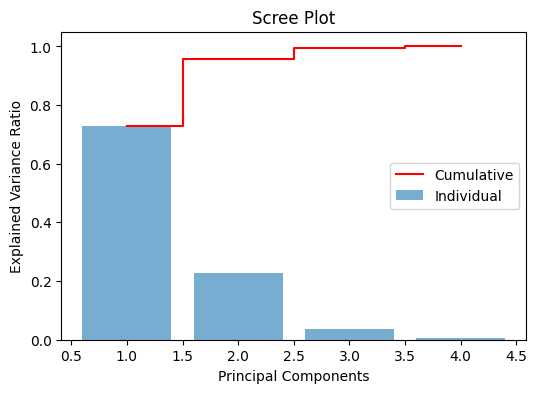

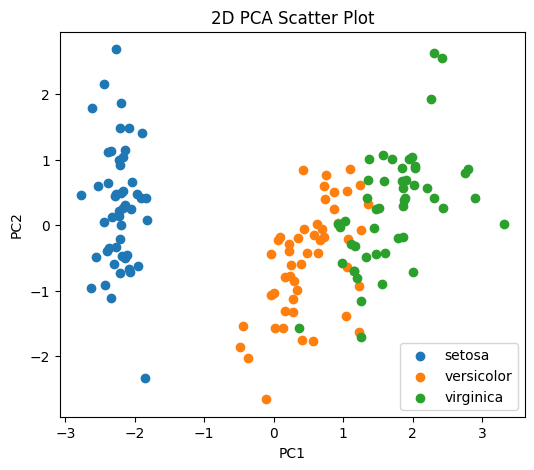

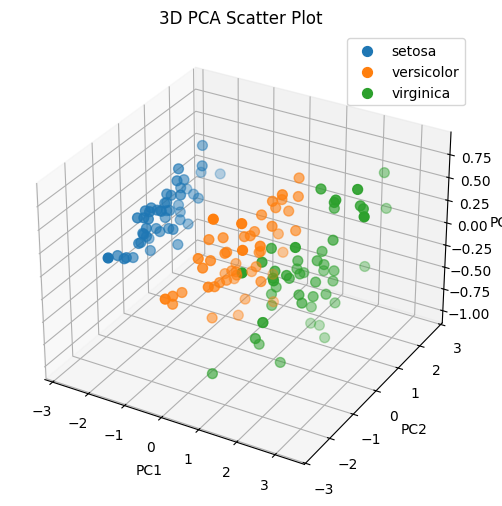

In [ ]:
#  1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#  2. Load Dataset
iris = load_iris()
X = iris.data  # Numerical features
y = iris.target  # Target labels (optional, for visualization)
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
print("Dataset Preview:")
print(df.head())

#  3. Handle Missing Values
# If any missing values exist, fill with mean
df.fillna(df.mean(), inplace=True)

# 4. Standardize Features -

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#  5. Apply PCA

# Reduce to all components first
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 6. Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio for each component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

print("\nCumulative Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f}")

# 7. Scree Plot
plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', label='Cumulative', color='red')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend()
plt.show()

#8. Reduce Dimensions to 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 2D Scatter Plot
plt.figure(figsize=(6,5))
for target in np.unique(y):
    plt.scatter(X_pca_2d[y==target,0], X_pca_2d[y==target,1], label=iris.target_names[target])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Scatter Plot')
plt.legend()
plt.show()

# 9. Reduce Dimensions to 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 3D Scatter Plot
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
for target in np.unique(y):
    ax.scatter(X_pca_3d[y==target,0], X_pca_3d[y==target,1], X_pca_3d[y==target,2],
               label=iris.target_names[target], s=50)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Scatter Plot')
ax.legend()
plt.show()